# S-Aging -- YOLOv11 Instance Segmentation Training

**Goal:** Train a YOLOv11-seg model to detect and segment banana leaf diseases.

| ID | Class |
|----|-------|
| 0 | Black_Sigatoka |
| 1 | Fusarium_Wilt |
| 2 | Healthy |

**Key techniques:**
- Auto-generated leaf-contour polygons via OpenCV (no manual annotation needed)
- Stratified split with minority-class oversampling
- Two-phase training (frozen backbone -> full fine-tune)
- Boosted classification loss + label smoothing
- Post-training diagnostic & ONNX verification

## 1. Setup

In [1]:
!pip install -q ultralytics scikit-learn opencv-python-headless

import torch, os, shutil, yaml, random, math, glob, cv2
import numpy as np
from pathlib import Path
from collections import Counter
from ultralytics import YOLO

print(f"PyTorch {torch.__version__}  |  CUDA {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")
else:
    print("[!]  No GPU -- go to Runtime -> Change runtime type -> GPU")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch 2.10.0+cu128  |  CUDA True
GPU: Tesla T4 (15.6 GB)


## 2. Mount Drive & Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# -- EDIT THIS PATH if your dataset is elsewhere --
DRIVE_DATASET = Path("/content/drive/MyDrive/Datasets")
assert DRIVE_DATASET.exists(), f"NOT FOUND: {DRIVE_DATASET}"

CLASS_MAP = {"Black_Sigatoka": 0, "Fusarium_Wilt": 1, "Healthy": 2}
IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

class_images = {}
for name in CLASS_MAP:
    d = DRIVE_DATASET / name
    if d.exists():
        class_images[name] = sorted([f for f in d.rglob("*") if f.suffix.lower() in IMG_EXTS])
    else:
        class_images[name] = []
        print(f"[!] {d} not found")

print("\n=== Dataset ===")
total = 0
for name, imgs in class_images.items():
    print(f"  {name:20s}: {len(imgs):4d} images")
    total += len(imgs)
print(f"  {'TOTAL':20s}: {total:4d} images")

mx = max(len(v) for v in class_images.values())
mn = min(len(v) for v in class_images.values() if len(v) > 0)
print(f"  Imbalance ratio: {mx/mn:.1f}x")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

=== Dataset ===
  Black_Sigatoka      : 5767 images
  Fusarium_Wilt       : 4697 images
  Healthy             : 6686 images
  TOTAL               : 17150 images
  Imbalance ratio: 1.4x


## 2b. CLAHE + Gamma Enhancement

Applied **before** every colour-based operation and before YOLO inference.
CLAHE boosts local contrast so lesion colours stand out; Gamma brightens dark spots.

In [ ]:
def apply_clahe(img_bgr, clip_limit=2.0, tile_grid=(8, 8)):
    """Contrast-Limited AHE on the L channel (LAB colour space)."""
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe_obj = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    l = clahe_obj.apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)


def apply_gamma(img_bgr, gamma=1.15):
    """Gamma correction — brightens dark disease regions."""
    inv_gamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** inv_gamma * 255
                      for i in range(256)]).astype("uint8")
    return cv2.LUT(img_bgr, table)


def enhance_image(img_bgr, clahe_clip=2.0, gamma=1.15):
    """CLAHE then Gamma correction — used throughout the pipeline."""
    return apply_gamma(apply_clahe(img_bgr, clahe_clip), gamma)


# ── Visualise effect on one sample per class ─────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(class_images), 3,
                         figsize=(18, 5 * len(class_images)))
for row, (cls_name, imgs) in enumerate(class_images.items()):
    if not imgs:
        continue
    img_bgr  = cv2.imread(str(imgs[0]))
    img_rgb  = cv2.cvtColor(img_bgr,                cv2.COLOR_BGR2RGB)
    cl_only  = cv2.cvtColor(apply_clahe(img_bgr),   cv2.COLOR_BGR2RGB)
    enhanced = cv2.cvtColor(enhance_image(img_bgr),  cv2.COLOR_BGR2RGB)

    axes[row, 0].imshow(img_rgb);   axes[row, 0].set_title(f"{cls_name} — Original");       axes[row, 0].axis("off")
    axes[row, 1].imshow(cl_only);   axes[row, 1].set_title("After CLAHE");                  axes[row, 1].axis("off")
    axes[row, 2].imshow(enhanced);  axes[row, 2].set_title("After CLAHE + Gamma (used)");   axes[row, 2].axis("off")

plt.suptitle("CLAHE + Gamma Preprocessing", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("enhance_image() ready.")

## 3. Auto-Annotate: Extract Leaf Contours with OpenCV

Instead of using a full-image rectangle (which gives the model background noise), we detect the actual **leaf contour** in each image using color segmentation.

This is the **critical fix** -- the old notebook used `0.01 0.01 0.99 0.01 0.99 0.99 0.01 0.99` (entire image) which included soil, sky, and other non-leaf regions, confusing the model.

In [ ]:
"""
S-AGING AUTO-ANNOTATION v10.2 (OPTIMIZED FOR LARGE DATASETS)
=============================================================
- GrabCut runs on downscaled image (max 640px), 2 iterations
- Healthy class uses fast hull (no GrabCut) -- saves ~1/3 of processing
- Leaf mask cache + detection result cache
- Black Sigatoka: GrabCut leaf mask + "not green" + watershed splitting
- Fusarium Wilt: LAB A-channel + ExG vegetation index (no GrabCut)
- Healthy: fast hull leaf contour (no GrabCut)
"""

import time
import matplotlib.pyplot as plt
from PIL import Image as PILImage

# -- CACHES ------------------------------------------------------------------
_leaf_mask_cache = {}   # img_path -> leaf_mask (full-res)
_detection_cache = {}   # (img_path, class_name) -> list of polygon strings

GRABCUT_MAX_DIM = 640


# ================================================================
# LEAF MASK: GrabCut-refined (for Black Sigatoka only)
# ================================================================

def _detect_leaf_mask_grabcut(img, img_path=None):
    """
    Detect leaf using GrabCut with seed-pixel hints.
    Downscales to max GRABCUT_MAX_DIM, runs 2 iterations, upscales back.
    """
    if img_path is not None:
        cache_key = str(img_path)
        if cache_key in _leaf_mask_cache:
            return _leaf_mask_cache[cache_key]

    h, w = img.shape[:2]
    total_px = h * w

    max_dim = max(h, w)
    if max_dim > GRABCUT_MAX_DIM:
        scale_factor = GRABCUT_MAX_DIM / max_dim
        small_w = int(w * scale_factor)
        small_h = int(h * scale_factor)
        img_small = cv2.resize(img, (small_w, small_h), interpolation=cv2.INTER_AREA)
    else:
        scale_factor = 1.0
        small_w, small_h = w, h
        img_small = img

    hsv = cv2.cvtColor(img_small, cv2.COLOR_BGR2HSV)
    sh, sw = img_small.shape[:2]
    total_px_small = sh * sw

    seeds = np.zeros((sh, sw), dtype=np.uint8)
    seeds |= cv2.inRange(hsv, (18, 25, 20), (95, 255, 255))
    seeds |= cv2.inRange(hsv, (12, 60, 80), (28, 255, 255))

    k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    seeds = cv2.morphologyEx(seeds, cv2.MORPH_OPEN, k_open)

    seed_count = cv2.countNonZero(seeds)
    if seed_count < 0.01 * total_px_small:
        result = np.ones((h, w), dtype=np.uint8) * 255
        if img_path is not None:
            _leaf_mask_cache[str(img_path)] = result
        return result

    erode_k = max(int(15 * scale_factor), 5)
    if erode_k % 2 == 0: erode_k += 1
    k_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (erode_k, erode_k))
    sure_fg = cv2.erode(seeds, k_erode, iterations=1)

    gc_mask = np.full((sh, sw), cv2.GC_PR_BGD, dtype=np.uint8)
    gc_mask[sure_fg > 0] = cv2.GC_FGD
    gc_mask[(seeds > 0) & (sure_fg == 0)] = cv2.GC_PR_FGD

    border = max(int(10 * scale_factor), 4)
    gc_mask[:border, :] = cv2.GC_BGD
    gc_mask[-border:, :] = cv2.GC_BGD
    gc_mask[:, :border] = cv2.GC_BGD
    gc_mask[:, -border:] = cv2.GC_BGD

    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    try:
        cv2.grabCut(img_small, gc_mask, None, bgd_model, fgd_model, 2, cv2.GC_INIT_WITH_MASK)
    except cv2.error:
        result = _detect_leaf_mask_hull(img)
        if img_path is not None:
            _leaf_mask_cache[str(img_path)] = result
        return result

    fg_mask = np.where((gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD), 255, 0).astype(np.uint8)

    if scale_factor < 1.0:
        fg_mask = cv2.resize(fg_mask, (w, h), interpolation=cv2.INTER_NEAREST)

    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21))
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, k_close)
    k_open2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, k_open2)

    if cv2.countNonZero(fg_mask) < 0.05 * total_px:
        result = _detect_leaf_mask_hull(img)
        if img_path is not None:
            _leaf_mask_cache[str(img_path)] = result
        return result

    contours, _ = cv2.findContours(fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        result = _detect_leaf_mask_hull(img)
        if img_path is not None:
            _leaf_mask_cache[str(img_path)] = result
        return result

    contours_sorted = sorted(contours, key=cv2.contourArea, reverse=True)
    total_area = sum(cv2.contourArea(c) for c in contours_sorted)
    selected = []
    accum = 0
    for c in contours_sorted:
        selected.append(c)
        accum += cv2.contourArea(c)
        if accum >= 0.70 * total_area:
            break

    all_pts = np.vstack(selected)
    hull = cv2.convexHull(all_pts)
    leaf_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(leaf_mask, [hull], 255)

    k_edge = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    leaf_mask = cv2.dilate(leaf_mask, k_edge, iterations=1)

    result = leaf_mask[:h, :w]
    if img_path is not None:
        _leaf_mask_cache[str(img_path)] = result
    return result


def _detect_leaf_mask_hull(img):
    """Fast fallback: top-components convex hull (no GrabCut)."""
    h, w = img.shape[:2]
    total_px = h * w
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    seeds = np.zeros((h, w), dtype=np.uint8)
    seeds |= cv2.inRange(hsv, (18, 25, 20), (95, 255, 255))
    seeds |= cv2.inRange(hsv, (12, 60, 80), (28, 255, 255))
    k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    seeds = cv2.morphologyEx(seeds, cv2.MORPH_OPEN, k_open)

    seed_count = cv2.countNonZero(seeds)
    if seed_count < 0.01 * total_px:
        return np.ones((h, w), dtype=np.uint8) * 255

    seed_pct = seed_count / total_px
    if seed_pct > 0.25:
        ksize = max(int(min(h, w) * 0.10), 51)
    else:
        ksize = 41
    if ksize % 2 == 0:
        ksize += 1
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    closed = cv2.morphologyEx(seeds, cv2.MORPH_CLOSE, k_close)

    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.ones((h, w), dtype=np.uint8) * 255

    contours_sorted = sorted(contours, key=cv2.contourArea, reverse=True)
    total_area = sum(cv2.contourArea(c) for c in contours_sorted)
    selected = []
    accum = 0
    for c in contours_sorted:
        selected.append(c)
        accum += cv2.contourArea(c)
        if accum >= 0.70 * total_area:
            break

    selected_mask = np.zeros((h, w), dtype=np.uint8)
    for c in selected:
        cv2.drawContours(selected_mask, [c], -1, 255, -1)

    dilate_r = max(int(min(h, w) * 0.05), 15)
    if dilate_r % 2 == 0:
        dilate_r += 1
    k_dilate = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate_r, dilate_r))
    expanded = cv2.dilate(selected_mask, k_dilate, iterations=1)

    main_seeds = cv2.bitwise_and(seeds, expanded)
    main_contours, _ = cv2.findContours(main_seeds, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not main_contours:
        all_pts = np.vstack(selected)
    else:
        all_pts = np.vstack(main_contours)
    hull = cv2.convexHull(all_pts)

    leaf_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(leaf_mask, [hull], 255)
    k_edge = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    leaf_mask = cv2.dilate(leaf_mask, k_edge, iterations=1)

    return leaf_mask[:h, :w]


# ================================================================
# BLACK SIGATOKA: "not green" within leaf + watershed splitting
# ================================================================

def _split_spots(disease_mask, img):
    """Split connected disease regions into separate spots via watershed."""
    h, w = disease_mask.shape[:2]
    num_orig, labels_orig = cv2.connectedComponents(disease_mask)
    all_instances = []

    for label_id in range(1, num_orig):
        component = np.zeros((h, w), dtype=np.uint8)
        component[labels_orig == label_id] = 255
        comp_area = cv2.countNonZero(component)

        if comp_area < 50:
            continue

        dist = cv2.distanceTransform(component, cv2.DIST_L2, 5)

        if dist.max() < 10:
            all_instances.append(component)
            continue

        thresh_val = max(0.30 * dist.max(), 8)
        _, peaks = cv2.threshold(dist, thresh_val, 255, cv2.THRESH_BINARY)
        peaks = peaks.astype(np.uint8)
        num_peaks, peak_labels = cv2.connectedComponents(peaks)

        if num_peaks <= 2:
            all_instances.append(component)
            continue

        markers = peak_labels.astype(np.int32) + 1
        markers[component == 0] = 1
        markers[(component > 0) & (peaks == 0)] = 0

        img_3ch = img if len(img.shape) == 3 else cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        markers_ws = cv2.watershed(img_3ch, markers.copy())

        for peak_id in range(2, num_peaks + 1):
            inst = np.zeros((h, w), dtype=np.uint8)
            inst[markers_ws == peak_id] = 255
            if cv2.countNonZero(inst) >= 50:
                all_instances.append(inst)

    return all_instances if all_instances else [disease_mask]


def _mask_to_polygon(mask, w, h, max_points=24):
    """Convert a single binary mask to a YOLO polygon string."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    cnt = max(contours, key=cv2.contourArea)
    peri = cv2.arcLength(cnt, True)
    if peri < 1:
        return None
    epsilon = 0.01 * peri
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    while len(approx) > max_points and epsilon < 0.1 * peri:
        epsilon *= 1.3
        approx = cv2.approxPolyDP(cnt, epsilon, True)
    if len(approx) < 3:
        return None
    pts = []
    for pt in approx:
        x = max(0.001, min(0.999, pt[0][0] / w))
        y = max(0.001, min(0.999, pt[0][1] / h))
        pts.append(f"{x:.4f} {y:.4f}")
    return " ".join(pts)


def _find_sigatoka_regions(img, leaf_mask, min_ratio=0.003, max_points=24):
    """Find Black Sigatoka spots: 'not green within leaf' + watershed split."""
    h, w = img.shape[:2]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    leaf_area = cv2.countNonZero(leaf_mask)
    if leaf_area < 100:
        return []

    green = cv2.inRange(hsv, (28, 25, 25), (85, 255, 255))
    green &= leaf_mask
    disease = cv2.bitwise_and(leaf_mask, cv2.bitwise_not(green))

    very_dark = cv2.inRange(hsv, (0, 0, 0), (180, 255, 8))
    disease = cv2.bitwise_and(disease, cv2.bitwise_not(very_dark))

    k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    disease = cv2.morphologyEx(disease, cv2.MORPH_OPEN, k_open)

    disease_area = cv2.countNonZero(disease)
    if disease_area < max(leaf_area * min_ratio, 50):
        return []

    instances = _split_spots(disease, img)

    min_area = max(leaf_area * min_ratio, 50)
    polygons = []
    for inst_mask in instances:
        if cv2.countNonZero(inst_mask) < min_area:
            continue
        poly = _mask_to_polygon(inst_mask, w, h, max_points)
        if poly:
            polygons.append(poly)

    return polygons


# ================================================================
# FUSARIUM WILT: LAB A-channel + ExG (fast, no GrabCut)
# ================================================================

def _find_fusarium_direct(img, min_ratio=0.005, max_points=28):
    """Detect Fusarium using LAB A-channel + ExG. No GrabCut needed."""
    h, w = img.shape[:2]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l_ch, a_ch, b_ch = cv2.split(lab)

    _, leaf_a = cv2.threshold(a_ch, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    yellow_b = np.zeros((h, w), dtype=np.uint8)
    yellow_b[(b_ch > 140) & (l_ch > 40)] = 255
    leaf_lab = cv2.bitwise_or(leaf_a, yellow_b)

    b_bgr, g_bgr, r_bgr = cv2.split(img)
    r_f = r_bgr.astype(np.float32)
    g_f = g_bgr.astype(np.float32)
    b_f = b_bgr.astype(np.float32)
    total = r_f + g_f + b_f + 1e-6
    exg = 2 * (g_f / total) - (r_f / total) - (b_f / total)

    veg_mask = np.zeros((h, w), dtype=np.uint8)
    veg_mask[exg > -0.05] = 255

    leaf_mask = cv2.bitwise_and(leaf_lab, veg_mask)

    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, k_close)
    k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_OPEN, k_open)

    leaf_area = cv2.countNonZero(leaf_mask)
    if leaf_area < 0.03 * h * w:
        leaf_mask = _detect_leaf_mask_hull(img)
        leaf_area = cv2.countNonZero(leaf_mask)

    green = cv2.inRange(hsv, (28, 25, 25), (85, 255, 255))
    green &= leaf_mask
    disease = cv2.bitwise_and(leaf_mask, cv2.bitwise_not(green))

    very_dark = cv2.inRange(hsv, (0, 0, 0), (180, 255, 10))
    disease = cv2.bitwise_and(disease, cv2.bitwise_not(very_dark))

    k_close2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    disease = cv2.morphologyEx(disease, cv2.MORPH_CLOSE, k_close2)
    k_open2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    disease = cv2.morphologyEx(disease, cv2.MORPH_OPEN, k_open2)

    return _contours_to_polygons(disease, w, h, leaf_area, min_ratio, max_points)


# ================================================================
# HEALTHY: fast hull leaf contour (no GrabCut needed)
# ================================================================

def _find_healthy_leaf(img, leaf_mask, max_points=28):
    """Annotate entire leaf contour for healthy images."""
    h, w = img.shape[:2]
    contours, _ = cv2.findContours(leaf_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return []

    min_area = 0.03 * h * w
    polygons = []
    for cnt in sorted(contours, key=cv2.contourArea, reverse=True)[:2]:
        if cv2.contourArea(cnt) < min_area:
            continue
        peri = cv2.arcLength(cnt, True)
        if peri < 1:
            continue
        epsilon = 0.005 * peri
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        while len(approx) > max_points and epsilon < 0.08 * peri:
            epsilon *= 1.4
            approx = cv2.approxPolyDP(cnt, epsilon, True)
        if len(approx) < 3:
            continue
        pts = []
        for pt in approx:
            x = max(0.001, min(0.999, pt[0][0] / w))
            y = max(0.001, min(0.999, pt[0][1] / h))
            pts.append(f"{x:.4f} {y:.4f}")
        polygons.append(" ".join(pts))
    return polygons


# ================================================================
# HELPER: mask contours -> YOLO polygon strings
# ================================================================

def _contours_to_polygons(mask, w, h, ref_area, min_ratio, max_points):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return []

    min_area = max(ref_area * min_ratio, 50)
    polygons = []
    for cnt in sorted(contours, key=cv2.contourArea, reverse=True):
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue
        peri = cv2.arcLength(cnt, True)
        if peri < 1:
            continue
        epsilon = 0.01 * peri
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        while len(approx) > max_points and epsilon < 0.1 * peri:
            epsilon *= 1.3
            approx = cv2.approxPolyDP(cnt, epsilon, True)
        if len(approx) < 3:
            continue
        pts = []
        for pt in approx:
            x = max(0.001, min(0.999, pt[0][0] / w))
            y = max(0.001, min(0.999, pt[0][1] / h))
            pts.append(f"{x:.4f} {y:.4f}")
        polygons.append(" ".join(pts))
    return polygons


# ================================================================
# PUBLIC API
# ================================================================

def find_disease_instances(img_path, class_name, max_points=28):
    """
    Detect disease instances in an image.
    Returns list of polygon strings (one per instance).
    Results are cached so repeated calls (oversampled duplicates) are free.

    Performance notes:
    - Fusarium_Wilt: LAB + ExG only (~0.05s/img)
    - Healthy: fast hull only (~0.05s/img)
    - Black_Sigatoka: GrabCut + watershed (~0.5-2s/img) -- the slow one
    """
    cache_key = (str(img_path), class_name)
    if cache_key in _detection_cache:
        return _detection_cache[cache_key]

    img = cv2.imread(str(img_path))
    if img is None:
        _detection_cache[cache_key] = []
        return []
    img = enhance_image(img)  # CLAHE + Gamma before colour detection

    if class_name == "Fusarium_Wilt":
        polys = _find_fusarium_direct(img, max_points=max_points)
        _detection_cache[cache_key] = polys
        return polys

    if class_name == "Healthy":
        # Fast path: hull-based leaf mask (no GrabCut needed for whole-leaf)
        leaf_mask = _detect_leaf_mask_hull(img)
        polys = _find_healthy_leaf(img, leaf_mask, max_points=max_points)
        _detection_cache[cache_key] = polys
        return polys

    # Black_Sigatoka: needs GrabCut for accurate leaf boundary
    leaf_mask = _detect_leaf_mask_grabcut(img, img_path=img_path)
    if cv2.countNonZero(leaf_mask) < 100:
        _detection_cache[cache_key] = []
        return []

    polys = _find_sigatoka_regions(img, leaf_mask, max_points=max_points)

    if not polys:
        polys = _find_healthy_leaf(img, leaf_mask, max_points=max_points)

    _detection_cache[cache_key] = polys
    return polys


def fallback_ellipse(num_points=24):
    pts = []
    for i in range(num_points):
        a = 2 * math.pi * i / num_points
        x = max(0.01, min(0.99, 0.5 + 0.44 * math.cos(a)))
        y = max(0.01, min(0.99, 0.5 + 0.37 * math.sin(a)))
        pts.append(f"{x:.4f} {y:.4f}")
    return " ".join(pts)


ELLIPSE_FALLBACK = fallback_ellipse()


# ================================================================
# VISUALIZATION
# ================================================================

INSTANCE_COLORS = [
    (255, 50, 50), (50, 120, 255), (255, 200, 0), (0, 230, 120),
    (200, 50, 255), (255, 120, 50), (50, 255, 255), (255, 50, 200),
    (120, 255, 50), (180, 180, 50), (100, 100, 255), (255, 150, 150),
]

def visualize_annotations(img_rgb, polygons):
    overlay = img_rgb.copy()
    ih, iw = img_rgb.shape[:2]
    for idx, poly_str in enumerate(polygons):
        color = INSTANCE_COLORS[idx % len(INSTANCE_COLORS)]
        vals = poly_str.split()
        pts_px = []
        for i in range(0, len(vals), 2):
            px = int(float(vals[i]) * iw)
            py = int(float(vals[i + 1]) * ih)
            pts_px.append([px, py])
        pts_np = np.array(pts_px, dtype=np.int32)
        mask_img = np.zeros_like(img_rgb)
        cv2.fillPoly(mask_img, [pts_np], color)
        overlay = cv2.addWeighted(overlay, 1.0, mask_img, 0.35, 0)
        cv2.drawContours(overlay, [pts_np], -1, color, 2)
        for pt in pts_px:
            cv2.circle(overlay, tuple(pt), 4, (255, 255, 255), -1)
            cv2.circle(overlay, tuple(pt), 4, color, 1)
    return overlay


# ==================================================================
# DIAGNOSTIC: 1 sample per class (pipeline visualization)
# ==================================================================

_t_start = time.time()
print("=" * 60)
print("DIAGNOSTIC -- v10.2 (GrabCut + LAB/ExG + Watershed)")
print("=" * 60)

for cls_name, imgs in class_images.items():
    if not imgs:
        continue

    img_path = imgs[0]
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ih, iw = img.shape[:2]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    polys = find_disease_instances(img_path, cls_name)
    annotated = visualize_annotations(img_rgb, polys) if polys else img_rgb.copy()

    if cls_name == "Fusarium_Wilt":
        l_ch, a_ch, b_ch = cv2.split(lab)
        _, leaf_a = cv2.threshold(a_ch, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        b_bgr, g_bgr, r_bgr = cv2.split(img)
        r_f = r_bgr.astype(np.float32); g_f = g_bgr.astype(np.float32); b_f = b_bgr.astype(np.float32)
        total_f = r_f + g_f + b_f + 1e-6
        exg = 2 * (g_f / total_f) - (r_f / total_f) - (b_f / total_f)
        exg_vis = ((exg - exg.min()) / (exg.max() - exg.min() + 1e-6) * 255).astype(np.uint8)

        fig, axes = plt.subplots(1, 5, figsize=(28, 5))
        axes[0].imshow(img_rgb); axes[0].set_title("Original"); axes[0].axis('off')
        axes[1].imshow(a_ch, cmap='RdYlGn_r'); axes[1].set_title("LAB A-channel\n(green=leaf, red=soil)"); axes[1].axis('off')
        axes[2].imshow(leaf_a, cmap='gray'); axes[2].set_title("LAB leaf mask (Otsu)"); axes[2].axis('off')
        axes[3].imshow(exg_vis, cmap='RdYlGn'); axes[3].set_title("ExG Index\n(green=veg, red=soil)"); axes[3].axis('off')
        axes[4].imshow(annotated); axes[4].set_title(f"Final: {len(polys)} inst."); axes[4].axis('off')

    elif cls_name == "Black_Sigatoka":
        leaf_mask = _detect_leaf_mask_grabcut(img, img_path=img_path)
        green_vis = cv2.inRange(hsv, (28, 25, 25), (85, 255, 255)) & leaf_mask
        disease_vis = cv2.bitwise_and(leaf_mask, cv2.bitwise_not(green_vis))
        very_dark_vis = cv2.inRange(hsv, (0, 0, 0), (180, 255, 8))
        disease_vis = cv2.bitwise_and(disease_vis, cv2.bitwise_not(very_dark_vis))

        fig, axes = plt.subplots(1, 5, figsize=(28, 5))
        axes[0].imshow(img_rgb); axes[0].set_title("Original"); axes[0].axis('off')
        seeds_vis = np.zeros((ih, iw), dtype=np.uint8)
        seeds_vis |= cv2.inRange(hsv, (18, 25, 20), (95, 255, 255))
        seeds_vis |= cv2.inRange(hsv, (12, 60, 80), (28, 255, 255))
        seed_ov = img_rgb.copy()
        seed_ov[seeds_vis > 0] = (seed_ov[seeds_vis > 0] * 0.5 + np.array([0, 255, 0]) * 0.5).astype(np.uint8)
        axes[1].imshow(seed_ov); axes[1].set_title("Seeds (GrabCut hints)"); axes[1].axis('off')
        axes[2].imshow(leaf_mask, cmap='gray')
        axes[2].set_title(f"GrabCut Mask ({cv2.countNonZero(leaf_mask)*100//(ih*iw)}%)"); axes[2].axis('off')
        axes[3].imshow(disease_vis, cmap='hot'); axes[3].set_title("Disease spots"); axes[3].axis('off')
        axes[4].imshow(annotated); axes[4].set_title(f"Final: {len(polys)} inst."); axes[4].axis('off')

    else:  # Healthy
        leaf_mask = _detect_leaf_mask_hull(img)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].imshow(img_rgb); axes[0].set_title("Original"); axes[0].axis('off')
        axes[1].imshow(leaf_mask, cmap='gray'); axes[1].set_title("Leaf Mask (hull)"); axes[1].axis('off')
        axes[2].imshow(annotated); axes[2].set_title(f"Final: {len(polys)} inst."); axes[2].axis('off')

    plt.suptitle(f"Diagnostic -- {cls_name} (v10.2)", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ==================================================================
# PREVIEW: 3 samples per class
# ==================================================================

print("\n" + "=" * 60)
print("ANNOTATION PREVIEW (3 samples per class)")
print("=" * 60)

num_samples = 3
fig, axes = plt.subplots(2 * num_samples, 3, figsize=(18, 6 * num_samples))

for col, (cls_name, imgs) in enumerate(class_images.items()):
    if not imgs:
        continue
    for s_idx in range(min(num_samples, len(imgs))):
        row_orig = s_idx * 2
        row_anno = s_idx * 2 + 1
        img_path = imgs[s_idx]
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[row_orig, col].imshow(img_rgb)
        axes[row_orig, col].set_title(f"{cls_name} #{s_idx+1}", fontsize=11)
        axes[row_orig, col].axis('off')

        polys = find_disease_instances(img_path, cls_name)
        if polys:
            overlay = visualize_annotations(img_rgb, polys)
            status = f"[OK] {len(polys)} inst."
        else:
            overlay = img_rgb.copy()
            status = "[X] None"
        axes[row_anno, col].imshow(overlay)
        axes[row_anno, col].set_title(f"Annotated ({status})", fontsize=10)
        axes[row_anno, col].axis('off')

plt.suptitle("Annotation Preview (v10.2)\nEach color = one instance",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

_t_end = time.time()
print(f"\nCell 3 time: {_t_end - _t_start:.1f}s ({(_t_end - _t_start)/60:.1f} min)")
print(f"Cache: {len(_leaf_mask_cache)} leaf masks, {len(_detection_cache)} detections")

Output hidden; open in https://colab.research.google.com to view.

## 4. Build YOLO Dataset (Stratified + Oversampled + Auto-Annotated)

In [ ]:
from sklearn.model_selection import train_test_split
from concurrent.futures import ThreadPoolExecutor, as_completed

LOCAL_DATASET = Path("/content/dataset")
if LOCAL_DATASET.exists():
    shutil.rmtree(LOCAL_DATASET)
for split in ["train", "val"]:
    (LOCAL_DATASET / split / "images").mkdir(parents=True)
    (LOCAL_DATASET / split / "labels").mkdir(parents=True)

# Collect all images with labels
all_imgs, all_labels = [], []
for name, cid in CLASS_MAP.items():
    for p in class_images[name]:
        all_imgs.append(p)
        all_labels.append(cid)

# Stratified 80/20 split
train_imgs, val_imgs, train_labels, val_labels = train_test_split(
    all_imgs, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

# Oversample minority classes in training set
train_dist = Counter(train_labels)
max_train = max(train_dist.values())
train_bal_imgs, train_bal_labels = [], []
for cid in range(len(CLASS_MAP)):
    idxs = [i for i, l in enumerate(train_labels) if l == cid]
    imgs_cls = [train_imgs[i] for i in idxs]
    n = len(imgs_cls)
    if n < max_train:
        extra = [imgs_cls[i % n] for i in range(max_train - n)]
        imgs_cls.extend(extra)
        print(f"  Oversampled {list(CLASS_MAP.keys())[cid]}: {n} -> {len(imgs_cls)}")
    train_bal_imgs.extend(imgs_cls)
    train_bal_labels.extend([cid] * len(imgs_cls))

print(f"\nTrain (balanced): {len(train_bal_imgs)}  |  Val: {len(val_imgs)}")

# ==================================================================
# STEP 1: Pre-cache all unique images in parallel (the expensive part)
# ==================================================================
# Oversampling creates duplicates -- only process each unique (path, class) once.
# ThreadPoolExecutor works because OpenCV's GrabCut releases the GIL.

_t_build = time.time()

unique_tasks = set()
for img_path, cid in zip(all_imgs, all_labels):
    cname = list(CLASS_MAP.keys())[cid]
    unique_tasks.add((str(img_path), cname))

print(f"\nPre-caching {len(unique_tasks)} unique images (parallel, {os.cpu_count()} threads)...")

# Count by class for ETA
cls_counts = Counter(cname for _, cname in unique_tasks)
for cname, cnt in cls_counts.items():
    speed = "~0.05s/img" if cname != "Black_Sigatoka" else "~0.5-2s/img (GrabCut)"
    print(f"  {cname}: {cnt} images ({speed})")

done_count = 0
fail_count = 0

def _process_one(task):
    img_path, cname = task
    polys = find_disease_instances(img_path, cname)
    return len(polys) > 0

NUM_WORKERS = min(8, os.cpu_count() or 4)

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = {executor.submit(_process_one, t): t for t in unique_tasks}
    for future in as_completed(futures):
        done_count += 1
        if not future.result():
            fail_count += 1
        if done_count % 500 == 0 or done_count == len(unique_tasks):
            elapsed = time.time() - _t_build
            rate = done_count / elapsed
            remaining = (len(unique_tasks) - done_count) / rate if rate > 0 else 0
            print(f"  {done_count}/{len(unique_tasks)} "
                  f"({elapsed:.0f}s elapsed, ~{remaining:.0f}s remaining)")

_t_precache = time.time()
print(f"\nPre-cache done in {_t_precache - _t_build:.0f}s ({(_t_precache - _t_build)/60:.1f} min)")
print(f"  {done_count - fail_count} detected, {fail_count} will use ellipse fallback")

# ==================================================================
# STEP 2: Build dataset (all cache hits -- fast sequential copy)
# ==================================================================

print("\nBuilding dataset (copying files + writing labels from cache)...")
auto_ok, auto_fail = 0, 0

def process_split(images, labels, split_name):
    global auto_ok, auto_fail
    seen = set()
    for idx, (img_path, cid) in enumerate(zip(images, labels)):
        cname = list(CLASS_MAP.keys())[cid]
        fname = f"{cname}_{idx:05d}{img_path.suffix.lower()}"
        while fname in seen:
            fname = f"{cname}_{idx:05d}_{random.randint(0,9999)}{img_path.suffix.lower()}"
        seen.add(fname)

        # Copy image
        dst = LOCAL_DATASET / split_name / "images" / fname
        shutil.copy2(img_path, dst)

        # Get cached detection results
        polys = find_disease_instances(img_path, cname)  # instant cache hit

        if polys:
            auto_ok += 1
        else:
            polys = [ELLIPSE_FALLBACK]
            auto_fail += 1

        # Write label: one line per instance (YOLO-seg format)
        label_path = LOCAL_DATASET / split_name / "labels" / (Path(fname).stem + ".txt")
        lines = [f"{cid} {poly}" for poly in polys]
        label_path.write_text("\n".join(lines) + "\n")

process_split(train_bal_imgs, train_bal_labels, "train")
process_split(val_imgs, val_labels, "val")

_t_end = time.time()
print(f"\nAuto-annotation: {auto_ok} detected, {auto_fail} fallback to ellipse")
print(f"Success rate: {auto_ok/(auto_ok+auto_fail)*100:.0f}%")
print(f"Total Cell 4 time: {_t_end - _t_build:.0f}s ({(_t_end - _t_build)/60:.1f} min)")
print(f"Cache: {len(_leaf_mask_cache)} leaf masks, {len(_detection_cache)} detections")

  Oversampled Black_Sigatoka: 4614 -> 5349
  Oversampled Fusarium_Wilt: 3757 -> 5349

Train (balanced): 16047  |  Val: 3430

Pre-caching 17150 unique images (parallel, 12 threads)...
  Healthy: 6686 images (~0.05s/img)
  Black_Sigatoka: 5767 images (~0.5-2s/img (GrabCut))
  Fusarium_Wilt: 4697 images (~0.05s/img)
  500/17150 (199s elapsed, ~6632s remaining)
  1000/17150 (271s elapsed, ~4381s remaining)
  1500/17150 (342s elapsed, ~3567s remaining)
  2000/17150 (411s elapsed, ~3116s remaining)
  2500/17150 (479s elapsed, ~2807s remaining)
  3000/17150 (549s elapsed, ~2591s remaining)
  3500/17150 (618s elapsed, ~2411s remaining)
  4000/17150 (685s elapsed, ~2253s remaining)
  4500/17150 (753s elapsed, ~2118s remaining)
  5000/17150 (825s elapsed, ~2004s remaining)
  5500/17150 (897s elapsed, ~1900s remaining)
  6000/17150 (964s elapsed, ~1792s remaining)
  6500/17150 (1034s elapsed, ~1694s remaining)
  7000/17150 (1105s elapsed, ~1602s remaining)
  7500/17150 (1174s elapsed, ~1511s rema

## 5. Create data.yaml & Verify Labels

In [ ]:
data_config = {
    "path": str(LOCAL_DATASET),
    "train": "train/images",
    "val":   "val/images",
    "nc": 3,
    "names": ["Black_Sigatoka", "Fusarium_Wilt", "Healthy"],
}
DATA_YAML = str(LOCAL_DATASET / "data.yaml")
with open(DATA_YAML, "w") as f:
    yaml.dump(data_config, f, sort_keys=False)

print("data.yaml:")
print(Path(DATA_YAML).read_text())

# Verify label distribution
for split in ["train", "val"]:
    ldir = LOCAL_DATASET / split / "labels"
    cls_ids = [int(f.read_text().strip().split()[0]) for f in ldir.glob("*.txt")]
    print(f"{split} labels:")
    for cid, cnt in sorted(Counter(cls_ids).items()):
        print(f"  {data_config['names'][cid]}: {cnt}")

data.yaml:
path: /content/dataset
train: train/images
val: val/images
nc: 3
names:
- Black_Sigatoka
- Fusarium_Wilt
- Healthy

train labels:
  Black_Sigatoka: 5349
  Fusarium_Wilt: 5349
  Healthy: 5349
val labels:
  Black_Sigatoka: 1153
  Fusarium_Wilt: 940
  Healthy: 1337


## 6. Train -- Phase 1: Frozen Backbone (Learn Disease Features)

Freeze the pretrained backbone (first 10 layers) and only train the detection head.
This prevents the model from forgetting its pretrained feature extraction abilities while it learns to distinguish our 3 classes.

In [ ]:
model = YOLO("yolo11s-seg.pt")

print("Phase 1: Frozen backbone -- training detection head only...")
results_p1 = model.train(
    data=DATA_YAML,
    epochs=30,
    imgsz=640,
    batch=16,
    patience=30,           # don't early-stop in phase 1
    save=True,
    device=0,

    # Freeze backbone (first 10 layers)
    freeze=10,

    # Higher LR since only head is trainable
    optimizer="AdamW",
    lr0=0.005,
    lrf=0.1,
    weight_decay=0.0005,
    warmup_epochs=3,
    cos_lr=True,

    # Mild augmentation for phase 1
    hsv_h=0.01,
    hsv_s=0.4,
    hsv_v=0.3,
    degrees=10.0,
    translate=0.1,
    scale=0.3,
    fliplr=0.5,
    mosaic=0.8,
    mixup=0.0,
    copy_paste=0.0,
    erasing=0.1,

    # Heavy classification focus
    box=7.5,
    cls=4.0,
    dfl=1.5,
    label_smoothing=0.1,

    project="/content/runs",
    name="saging_p1",
    exist_ok=True,
    verbose=True,
)
print("\n[OK] Phase 1 complete.")

Phase 1: Frozen backbone -- training detection head only...
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=4.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.1, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.01, hsv_s=0.4, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mos

## 7. Train -- Phase 2: Full Fine-Tuning

Unfreeze everything and fine-tune the full model with a lower learning rate, strong augmentation, and boosted classification loss.

In [ ]:
# Load best weights from phase 1
p1_best = Path("/content/runs/saging_p1/weights/best.pt")
model2 = YOLO(str(p1_best))

print("Phase 2: Full fine-tuning (all layers unfrozen)...")
results_p2 = model2.train(
    data=DATA_YAML,
    epochs=200,
    imgsz=640,
    batch=16,
    patience=40,
    save=True,
    save_period=25,
    device=0,

    # No freeze -- all layers trainable
    freeze=0,

    # Lower LR for fine-tuning
    optimizer="AdamW",
    lr0=0.0008,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=5,
    warmup_momentum=0.8,
    cos_lr=True,

    # Full augmentation (tuned for leaf disease color cues)
    hsv_h=0.015,           # subtle hue -- preserve disease color fingerprint
    hsv_s=0.7,             # saturation variation
    hsv_v=0.4,             # brightness variation
    degrees=15.0,
    translate=0.1,
    scale=0.5,
    shear=3.0,
    flipud=0.15,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.05,
    erasing=0.15,

    # Loss weights -- classification heavily boosted
    box=7.5,
    cls=3.0,
    dfl=1.5,
    label_smoothing=0.05,

    project="/content/runs",
    name="saging_p2",
    exist_ok=True,
    plots=True,
    verbose=True,
)
print("\n[OK] Phase 2 complete.")

Phase 2: Full fine-tuning (all layers unfrozen)...
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=3.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.05, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.15, exist_ok=True, fliplr=0.5, flipud=0.15, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0008, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/runs/saging_p1/weights/best.p

## 8. Training Curves & Confusion Matrix


results.png:


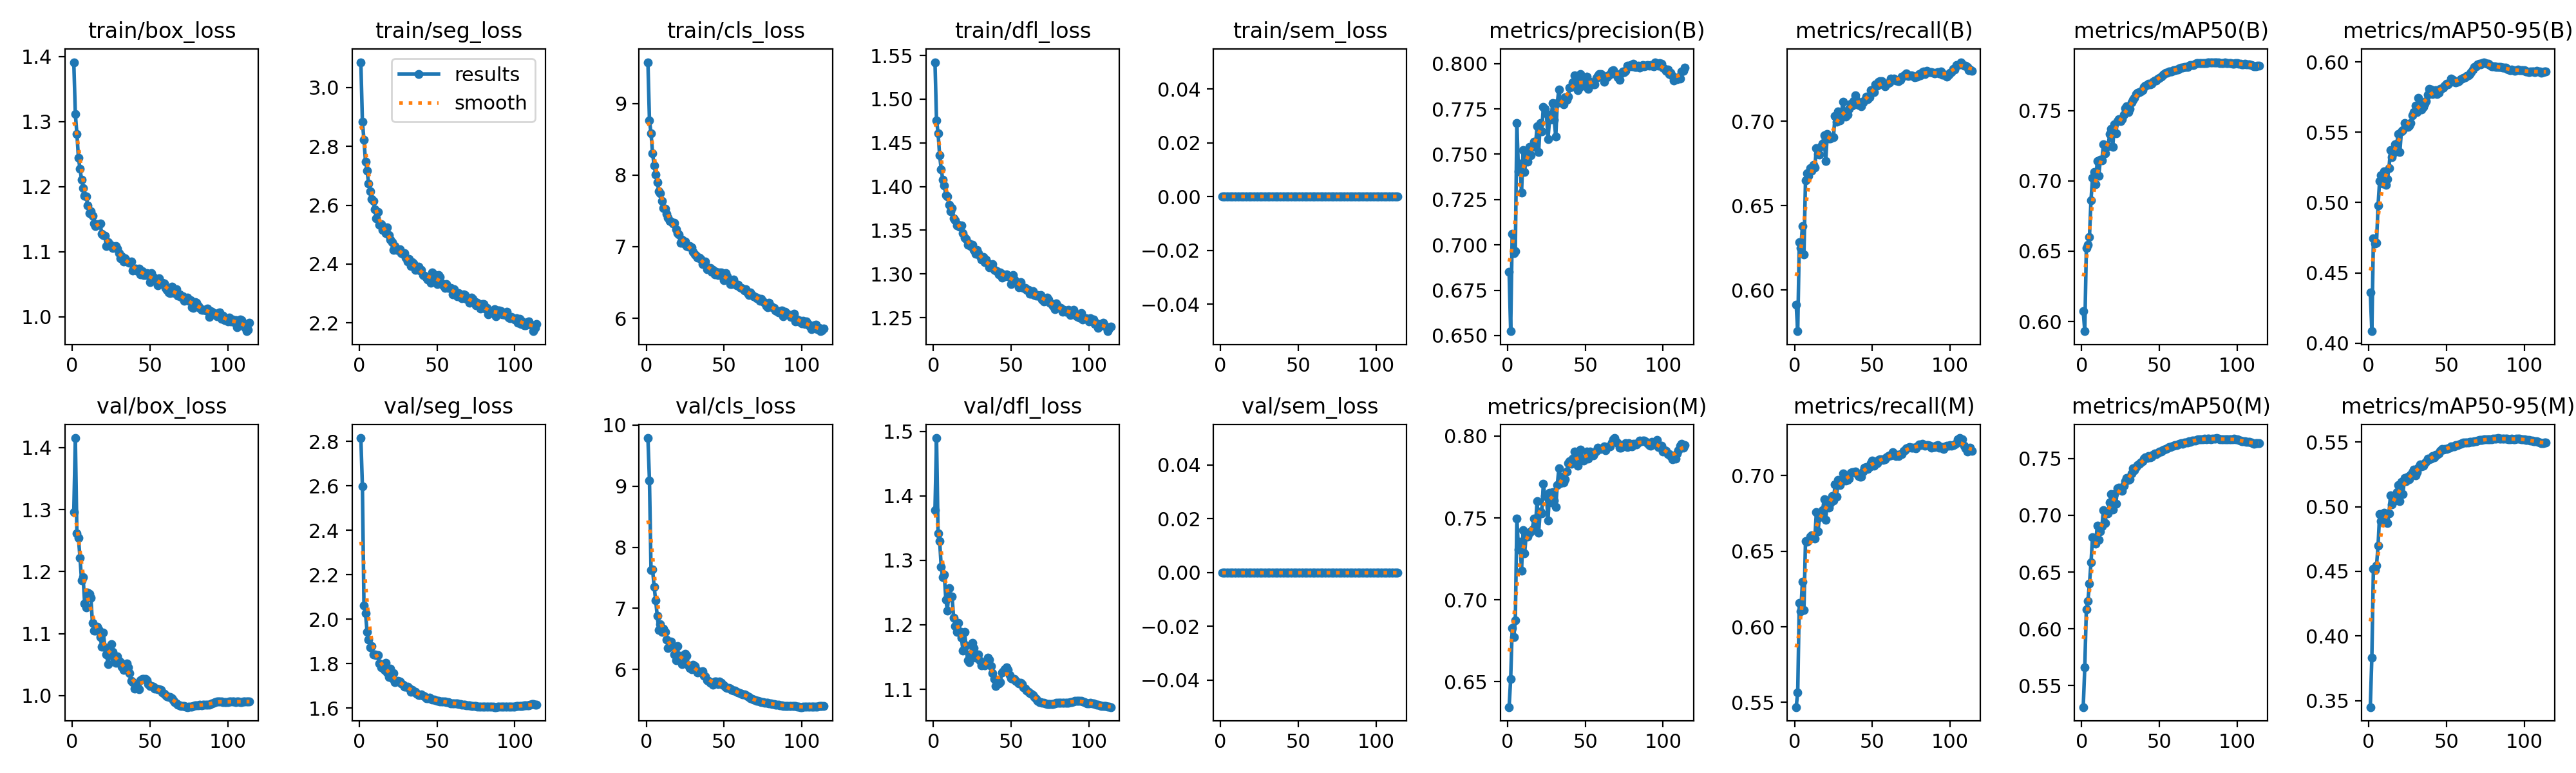


confusion_matrix_normalized.png:


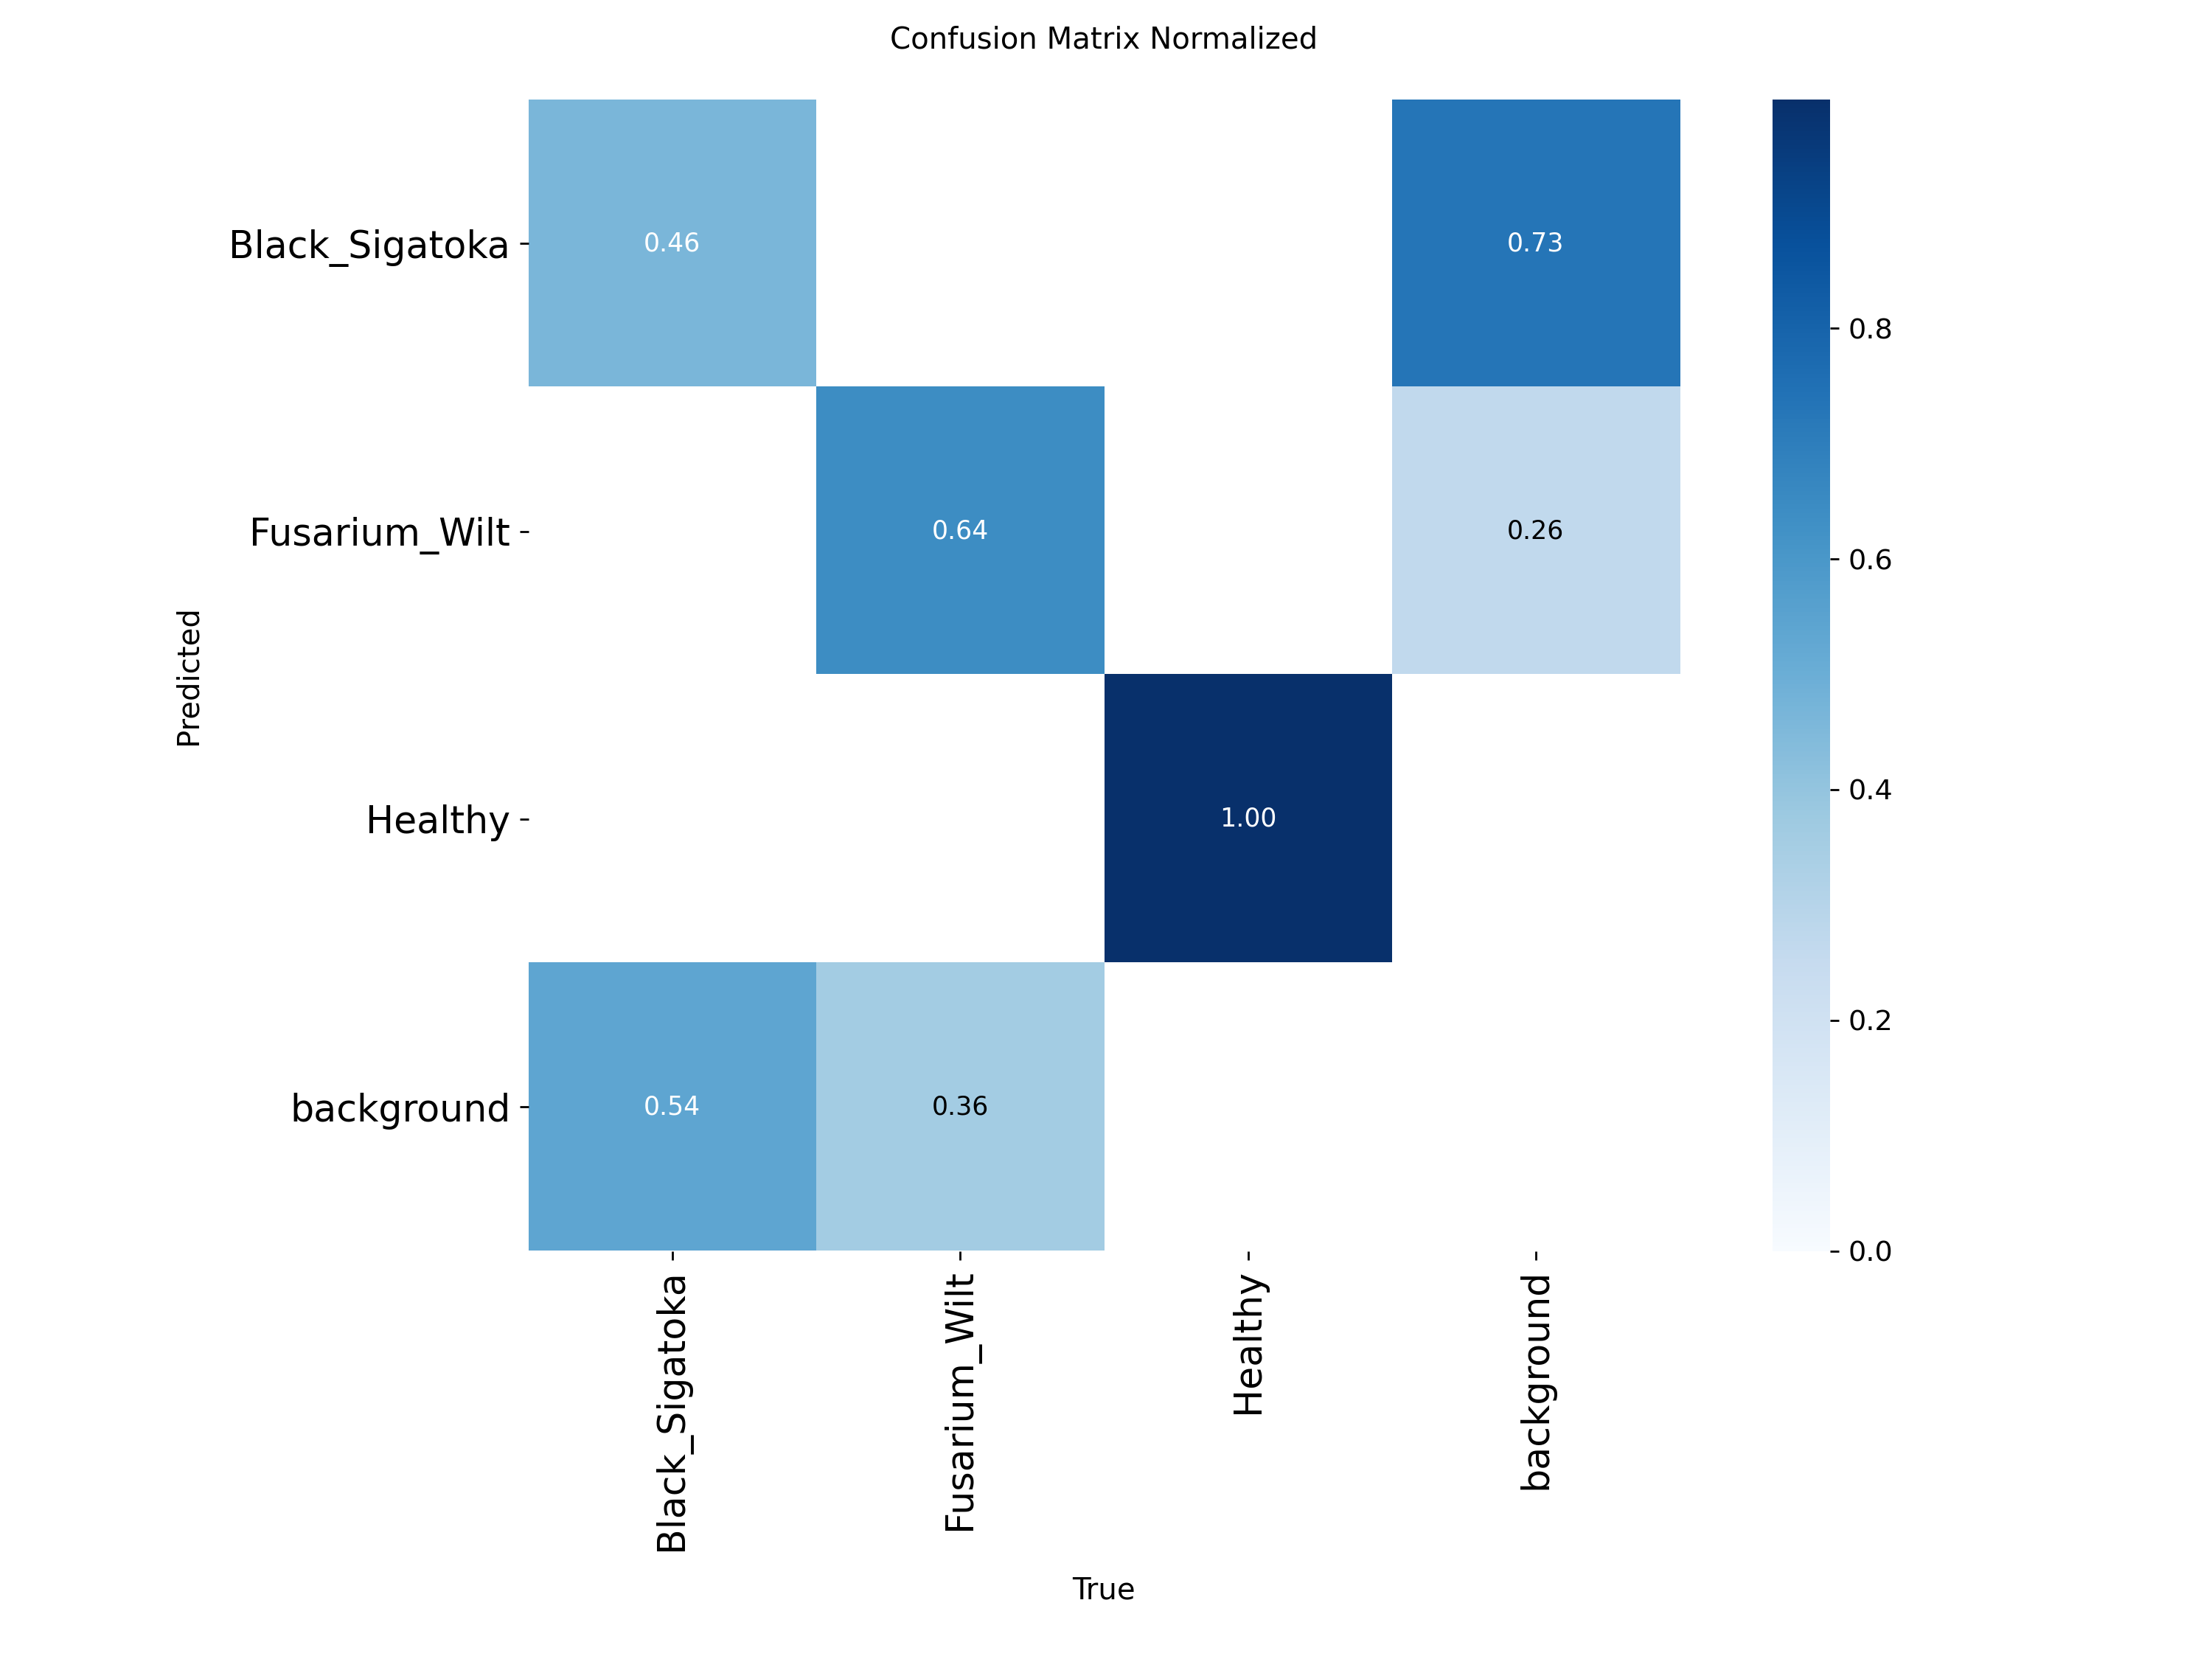


confusion_matrix.png:


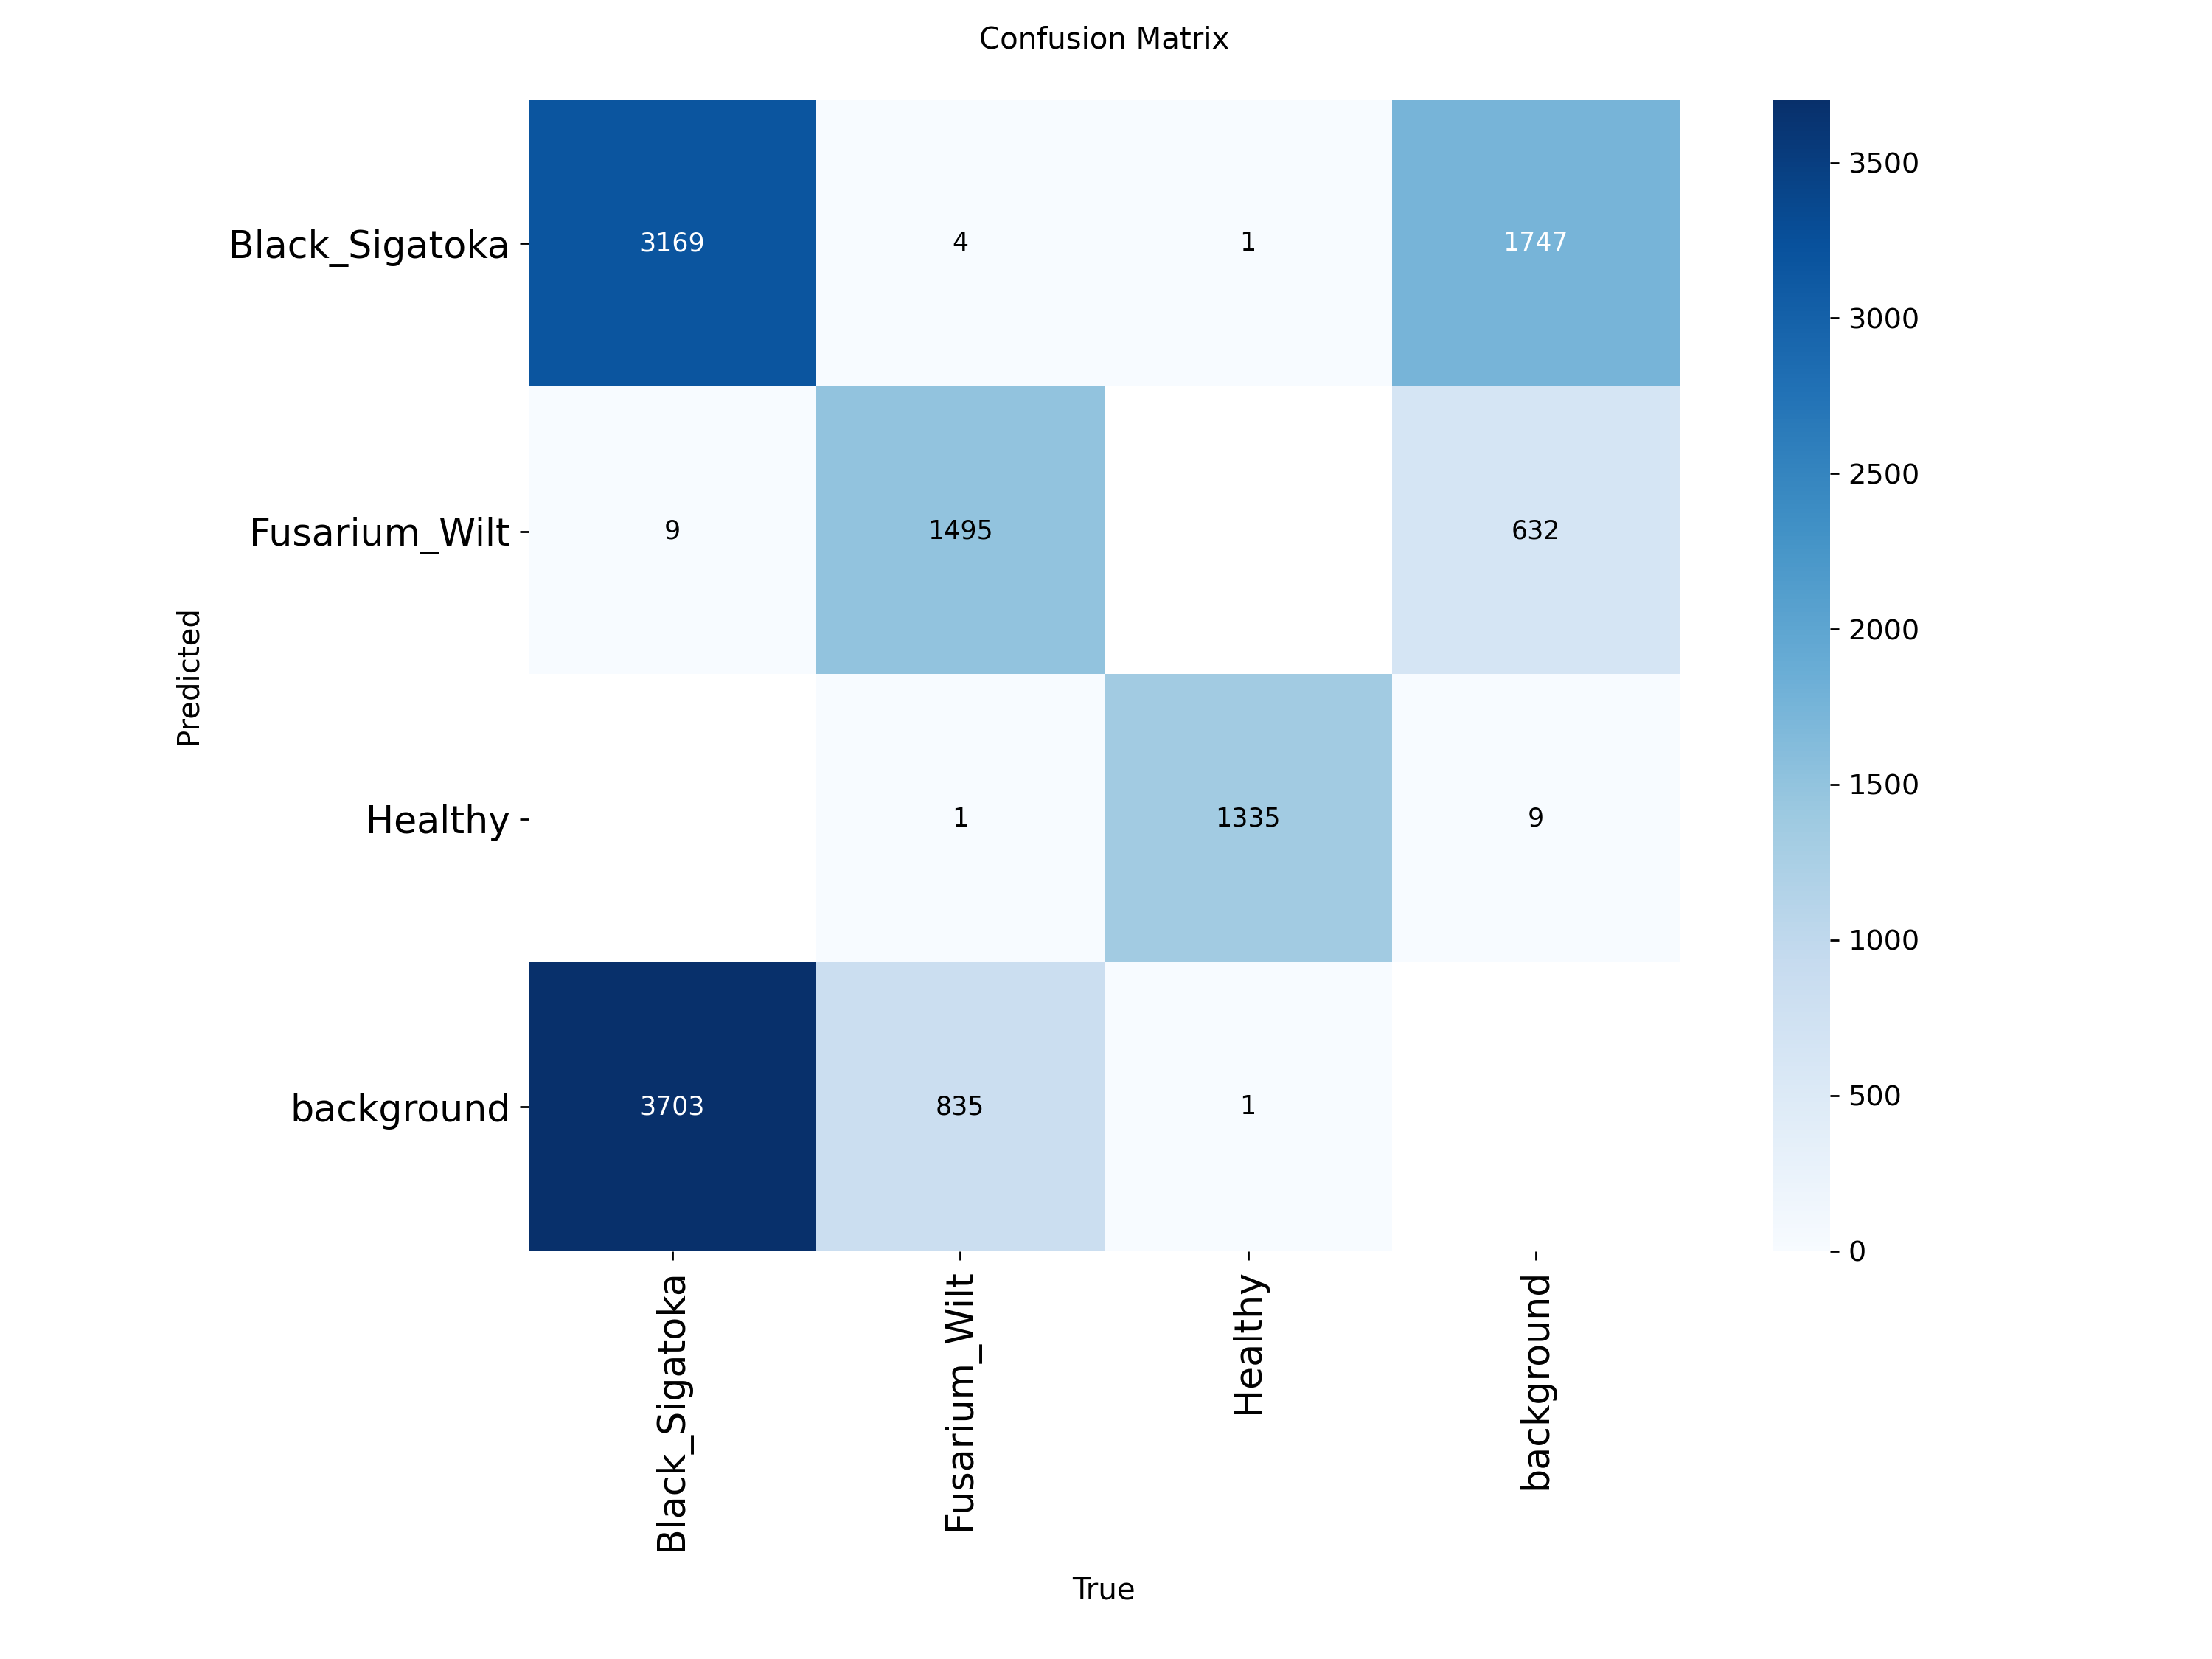

In [ ]:
from IPython.display import Image, display

run_dir = Path("/content/runs/saging_p2")

for fname in ["results.png", "confusion_matrix_normalized.png", "confusion_matrix.png",
              "val_batch0_pred.png", "val_batch1_pred.png"]:
    p = run_dir / fname
    if p.exists():
        print(f"\n{fname}:")
        display(Image(filename=str(p), width=800 if "results" in fname else 600))

## 9. Validate -- Per-Class Metrics

In [ ]:
best_pt = run_dir / "weights" / "best.pt"
best_model = YOLO(str(best_pt))

metrics = best_model.val(data=DATA_YAML, imgsz=640, device=0, plots=True)

names = best_model.names
print("\n" + "=" * 60)
print(f"Mask  mAP@0.5 = {metrics.seg.map50:.4f}   |   Box  mAP@0.5 = {metrics.box.map50:.4f}")
print("=" * 60)

# Per-class metrics (works across ultralytics versions)
try:
    ap50_values = metrics.seg.ap50
except AttributeError:
    ap50_values = metrics.seg.class_result(verbose=False)[:, 0]

for i, ap50 in enumerate(ap50_values):
    s = "[OK]" if ap50 > 0.5 else "[!]" if ap50 > 0.3 else "[X]"
    print(f"  {s} {names[i]:20s} mAP@0.5 = {ap50:.4f}")

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11s-seg summary (fused): 114 layers, 10,067,977 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1944.8±1230.8 MB/s, size: 336.5 KB)
val: Scanning /content/dataset/val/labels.cache... 3430 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3430/3430 1.3Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 215/215 6.3it/s 34.0s
                   all       3430      10553      0.765      0.693      0.737      0.549       0.76      0.684      0.718      0.516
        Black_Sigatoka       1153       6881      0.622      0.449      0.526      0.293      0.617       0.44      0.505      0.238
         Fusarium_Wilt        940       2335      0.682      0.632      0.693      0.456      0.671      0.615      0.657      0.337
               Healthy       1337   

## 10. Diagnostic -- Per-Image Test

The most important check: does the model correctly classify individual images?

In [ ]:
val_dir = LOCAL_DATASET / "val" / "images"
right, wrong, total = 0, 0, 0

print("=" * 60)
print("PER-IMAGE CLASSIFICATION TEST")
print("=" * 60)

for cls_name in CLASS_MAP:
    imgs = sorted(glob.glob(str(val_dir / f"{cls_name}_*")))[:5]
    print(f"\n-- True class: {cls_name} --")
    for p in imgs:
        total += 1
        res = best_model.predict(source=p, imgsz=640, conf=0.1, device=0, verbose=False)
        r = res[0]
        if r.boxes is not None and len(r.boxes) > 0:
            # Take highest-confidence detection
            best_idx = int(r.boxes.conf.argmax())
            cid = int(r.boxes.cls[best_idx])
            conf = float(r.boxes.conf[best_idx])
            pred = names[cid]
            ok = pred == cls_name
            if ok: right += 1
            else: wrong += 1
            sym = "[OK]" if ok else "[X]"
            print(f"  {Path(p).name}: {pred} ({conf:.2f}) {sym}")
        else:
            wrong += 1
            print(f"  {Path(p).name}: NO DETECTION [X]")

acc = right / total * 100 if total > 0 else 0
print(f"\n{'=' * 60}")
print(f"Accuracy: {acc:.0f}%  ({right}/{total} correct)")
if acc >= 80:
    print("[OK] Model is classifying well -- safe to deploy!")
elif acc >= 60:
    print("[!]  Moderate accuracy -- consider adding more training images")
else:
    print("[X] Low accuracy -- model needs more/better data")
    print("   Try: (1) more images per class  (2) proper polygon annotations via Roboflow")

PER-IMAGE CLASSIFICATION TEST

-- True class: Black_Sigatoka --
  Black_Sigatoka_00005.jpg: Black_Sigatoka (0.40) [OK]
  Black_Sigatoka_00007.jpg: Black_Sigatoka (0.69) [OK]
  Black_Sigatoka_00008.jpg: Black_Sigatoka (0.60) [OK]
  Black_Sigatoka_00009.jpg: Black_Sigatoka (0.31) [OK]
  Black_Sigatoka_00011.jpg: Black_Sigatoka (0.41) [OK]

-- True class: Fusarium_Wilt --
  Fusarium_Wilt_00001.jpg: Fusarium_Wilt (0.72) [OK]
  Fusarium_Wilt_00002.jpg: Fusarium_Wilt (0.84) [OK]
  Fusarium_Wilt_00006.jpg: Fusarium_Wilt (0.71) [OK]
  Fusarium_Wilt_00010.jpg: Fusarium_Wilt (0.35) [OK]
  Fusarium_Wilt_00024.jpg: Fusarium_Wilt (0.55) [OK]

-- True class: Healthy --
  Healthy_00000.jpg: NO DETECTION [X]
  Healthy_00003.jpg: NO DETECTION [X]
  Healthy_00004.jpg: Healthy (0.94) [OK]
  Healthy_00014.jpg: NO DETECTION [X]
  Healthy_00020.jpg: Healthy (0.91) [OK]

Accuracy: 80%  (12/15 correct)
[OK] Model is classifying well -- safe to deploy!


## 10b. Two-Stage Inference Pipeline

Full pipeline matching the original spec:

| Stage | What happens |
|-------|-------------|
| 1 | CLAHE + Gamma enhancement |
| 2 | Colour-based leaf detection → crop leaf only, black out background |
| 3 | CLAHE + Gamma on cropped leaf |
| 4 | YOLO11-SEG predict → disease label + segmentation masks |

In [ ]:
# ── Stage helpers ─────────────────────────────────────────────────────────────

LABEL_COLOURS = {
    "Black_Sigatoka": (255, 80,  80),
    "Fusarium_Wilt":  (80,  80, 255),
    "Healthy":        (80, 220,  80),
}


def crop_to_leaf(img_bgr, margin=15):
    """
    Stage 1+2: enhance → hull leaf mask → crop + black-out background.
    Returns (leaf_crop_bgr, (x1,y1,x2,y2), full_leaf_mask).
    """
    enhanced  = enhance_image(img_bgr)
    leaf_mask = _detect_leaf_mask_hull(enhanced)
    ih, iw    = img_bgr.shape[:2]
    ys, xs    = np.where(leaf_mask > 0)
    if len(xs) == 0:
        return enhanced, (0, 0, iw, ih), leaf_mask
    x1 = max(0,  int(xs.min()) - margin)
    y1 = max(0,  int(ys.min()) - margin)
    x2 = min(iw, int(xs.max()) + margin)
    y2 = min(ih, int(ys.max()) + margin)
    crop        = enhanced[y1:y2, x1:x2].copy()
    crop_mask   = leaf_mask[y1:y2, x1:x2]
    crop[crop_mask == 0] = 0          # remove background
    return crop, (x1, y1, x2, y2), leaf_mask


def run_pipeline(img_src, model, conf=0.20):
    """
    Full two-stage pipeline.
    img_src: file path (str/Path) or BGR numpy array.
    Returns result dict or None on read error.
    """
    img_bgr = cv2.imread(str(img_src)) if isinstance(img_src, (str, Path)) else img_src
    if img_bgr is None:
        return None

    # Stage 1 & 2: leaf detection + crop
    leaf_crop, bbox, leaf_mask = crop_to_leaf(img_bgr)

    # Stage 3: enhance cropped leaf
    leaf_enhanced = enhance_image(leaf_crop)

    # Stage 4: YOLO predict
    results = model.predict(source=leaf_enhanced, conf=conf, imgsz=640, verbose=False)
    r = results[0]

    label, confidence = "No Detection", 0.0
    if r.boxes is not None and len(r.boxes) > 0:
        best_idx   = int(r.boxes.conf.argmax())
        label      = model.names[int(r.boxes.cls[best_idx])]
        confidence = float(r.boxes.conf[best_idx])

    return dict(
        original      = img_bgr,
        leaf_crop     = leaf_crop,
        leaf_enhanced = leaf_enhanced,
        bbox          = bbox,
        leaf_mask     = leaf_mask,
        yolo_result   = r,
        label         = label,
        confidence    = confidence,
    )


def visualize_pipeline(out, true_label=None):
    """4-panel visualisation of the full pipeline result."""
    orig_rgb = cv2.cvtColor(out["original"],      cv2.COLOR_BGR2RGB)
    crop_rgb = cv2.cvtColor(out["leaf_crop"],      cv2.COLOR_BGR2RGB)
    enh_rgb  = cv2.cvtColor(out["leaf_enhanced"],  cv2.COLOR_BGR2RGB)

    # Panel 1: leaf bounding box on original
    p1 = orig_rgb.copy()
    x1, y1, x2, y2 = out["bbox"]
    cv2.rectangle(p1, (x1, y1), (x2, y2), (0, 255, 0), 3)

    # Panel 4: YOLO masks overlaid on enhanced crop
    p4 = enh_rgb.copy()
    r  = out["yolo_result"]
    ch, cw = p4.shape[:2]
    if r.masks is not None:
        for idx, mdata in enumerate(r.masks.data):
            mn = mdata.cpu().numpy()
            if mn.shape != (ch, cw):
                mn = cv2.resize(mn, (cw, ch), interpolation=cv2.INTER_NEAREST)
            col = INSTANCE_COLORS[idx % len(INSTANCE_COLORS)]
            ov  = np.zeros_like(p4)
            ov[mn > 0.5] = col
            p4 = cv2.addWeighted(p4, 1.0, ov, 0.40, 0)
    lc = LABEL_COLOURS.get(out["label"], (200, 200, 200))
    cv2.putText(p4, f"{out['label']} ({out['confidence']:.2f})",
                (8, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.75, lc, 2)

    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    axes[0].imshow(p1);       axes[0].set_title("Stage 1+2: Leaf Detected & Cropped"); axes[0].axis("off")
    axes[1].imshow(crop_rgb); axes[1].set_title("Stage 2: Background Removed");        axes[1].axis("off")
    axes[2].imshow(enh_rgb);  axes[2].set_title("Stage 3: CLAHE + Gamma on Leaf");    axes[2].axis("off")
    axes[3].imshow(p4);       axes[3].set_title(f"Stage 4: Disease Detection\n{out['label']} ({out['confidence']:.2f})"); axes[3].axis("off")

    if true_label:
        ok    = out["label"] == true_label
        title = f"Result: {out['label']}  |  True: {true_label}  {'[OK]' if ok else '[X]'}"
        col   = "green" if ok else "red"
    else:
        title = f"Result: {out['label']} ({out['confidence']:.2f})"
        col   = "black"
    plt.suptitle(title, fontsize=13, fontweight="bold", color=col)
    plt.tight_layout()
    plt.show()


# ── Demo: 2 random samples per class ─────────────────────────────────────────
import random as _rnd

try:
    best_model
except NameError:
    _bp = Path("/content/runs/saging_p2/weights/best.pt")
    best_model = YOLO(str(_bp))
    print(f"Loaded model from {_bp}")

print("=" * 60)
print("TWO-STAGE PIPELINE DEMO")
print("Stage 1+2 : CLAHE+Gamma → Leaf detect → Crop (bg removed)")
print("Stage 3   : CLAHE+Gamma on cropped leaf")
print("Stage 4   : YOLO11-SEG predict → classify")
print("=" * 60)

p_right, p_total = 0, 0
for cls_name, imgs in class_images.items():
    if not imgs:
        continue
    print(f"\n--- {cls_name} ---")
    for img_path in _rnd.sample(imgs, min(2, len(imgs))):
        out = run_pipeline(img_path, best_model, conf=0.15)
        if out is None:
            continue
        p_total += 1
        ok = out["label"] == cls_name
        if ok:
            p_right += 1
        print(f"  {Path(str(img_path)).name}: "
              f"{out['label']} ({out['confidence']:.2f}) "
              f"{'[OK]' if ok else '[X]'}")
        visualize_pipeline(out, true_label=cls_name)

acc = p_right / p_total * 100 if p_total else 0
print(f"\nPipeline accuracy: {acc:.0f}%  ({p_right}/{p_total})")

## 11. Export ONNX & Verify Output Shape

In [ ]:
onnx_path = best_model.export(
    format="onnx", imgsz=640, simplify=True, opset=17, dynamic=False, half=False,
)
print(f"Exported: {onnx_path}  ({Path(onnx_path).stat().st_size/1e6:.1f} MB)")

# Verify class order
print("\n=== Class Order ===")
expected = ['Black_Sigatoka', 'Fusarium_Wilt', 'Healthy']
actual = [best_model.names[i] for i in range(len(best_model.names))]
all_ok = True
for i, (e, a) in enumerate(zip(expected, actual)):
    m = '[OK]' if e == a else '[X]'
    if e != a: all_ok = False
    print(f"  {i}: {a} {m}")
if all_ok:
    print("[OK] Matches detection.js")
else:
    print(f"[X] UPDATE detection.js CLASS_NAMES to: {actual}")

# Verify ONNX output shape
!pip install -q onnxruntime
import onnxruntime as onnxrt

sess = onnxrt.InferenceSession(str(onnx_path))
dummy = np.random.randn(1, 3, 640, 640).astype(np.float32)
outs = sess.run(None, {sess.get_inputs()[0].name: dummy})

print(f"\n=== ONNX Outputs ===")
for i, o in enumerate(outs):
    print(f"  [{i}]: {o.shape}")

d1, d2 = outs[0].shape[1], outs[0].shape[2]
nf = min(d1, d2)
mask_c = outs[1].shape[1] if len(outs) >= 2 else 0
nc = nf - 4 - mask_c
print(f"\n  nc={nc} (expected 3), mask_coeffs={mask_c}")
if nc == 3:
    print("  [OK] Output shape correct")
else:
    print(f"  [X] nc mismatch! Check model export.")

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/saging_p2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 39, 8400), (1, 32, 160, 160)) (19.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 282ms
Prepared 4 packages in 3.27s
Installed 4 packages in 316ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 4.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 7.9s, save

## 12. Save to Google Drive

In [ ]:
DRIVE_OUTPUT = Path("/content/drive/MyDrive/saging_models")
DRIVE_OUTPUT.mkdir(parents=True, exist_ok=True)

shutil.copy2(best_pt, DRIVE_OUTPUT / "best.pt")
shutil.copy2(Path(onnx_path), DRIVE_OUTPUT / "best.onnx")

results_bak = DRIVE_OUTPUT / "training_results"
if results_bak.exists():
    shutil.rmtree(results_bak)
shutil.copytree(run_dir, results_bak, ignore=shutil.ignore_patterns("*.cache"))

print("Saved to Google Drive:")
print(f"  {DRIVE_OUTPUT / 'best.pt'}")
print(f"  {DRIVE_OUTPUT / 'best.onnx'}")
print(f"  {results_bak}")

print(f"\n{'=' * 60}")
print("NEXT STEPS:")
print("1. Download best.onnx from Google Drive")
print("2. Replace -> s-aging-app/public/best.onnx")
print("3. Run -> npm run dev")
print("4. Upload a diseased leaf image and verify detection")

Saved to Google Drive:
  /content/drive/MyDrive/saging_models/best.pt
  /content/drive/MyDrive/saging_models/best.onnx
  /content/drive/MyDrive/saging_models/training_results

NEXT STEPS:
1. Download best.onnx from Google Drive
2. Replace -> s-aging-app/public/best.onnx
3. Run -> npm run dev
4. Upload a diseased leaf image and verify detection
